# Task 2: Quantitative Analysis Using TA-Lib and PyNance

## Objective
Load historical stock price data, compute financial technical indicators,
and visualize the results to understand market behavior for AAPL, AMZN,
GOOG, META, and NVDA.

## Technical Indicators Covered
- **Simple Moving Average (SMA)** — trend direction
- **Exponential Moving Average (EMA)** — trend with more weight on recent prices
- **RSI** — overbought/oversold conditions
- **MACD** — momentum shifts and trend reversals
- **Bollinger Bands** — volatility and price channels

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
import warnings
warnings.filterwarnings('ignore')

os.chdir(r"C:\Users\pc\news-sentiment-analysis")

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['figure.dpi'] = 100

print(f"TA-Lib version: {talib.__version__}")
print("All imports successful")

TA-Lib version: 0.6.8
All imports successful


## Data Loading and Preparation

We load historical stock price data for five major technology stocks.
Each CSV contains daily OHLCV data (Open, High, Low, Close, Volume).
We ensure correct data types and handle any missing values before
computing technical indicators.

In [4]:
stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
stock_data = {}

for stock in stocks:
    df = pd.read_csv(f"data/raw/{stock}.csv")
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Ensure correct types
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Handle missing values
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f"{stock}: Found {missing} missing values — forward filling")
        df.ffill(inplace=True)
    
    stock_data[stock] = df
    print(f"{stock}: {len(df)} rows | {df['Date'].min().date()} to {df['Date'].max().date()}")

print("\nAll stocks loaded successfully")

AAPL: 3774 rows | 2009-01-02 to 2023-12-29
AMZN: 3774 rows | 2009-01-02 to 2023-12-29
GOOG: 3774 rows | 2009-01-02 to 2023-12-29
META: 2923 rows | 2012-05-18 to 2023-12-29
NVDA: 3774 rows | 2009-01-02 to 2023-12-29

All stocks loaded successfully


## Data Quality Summary

The dataset spans multiple years of daily trading data. All columns
are correctly typed as float64 for price data and int64 for volume.
Missing values are handled using forward-fill which preserves the
time series continuity — the last known price is carried forward
for any missing trading days.

In [5]:
for stock in stocks:
    df = stock_data[stock]
    close = df['Close'].values
    high = df['High'].values
    low = df['Low'].values
    
    # Moving Averages
    df['SMA_20'] = talib.SMA(close, timeperiod=20)
    df['SMA_50'] = talib.SMA(close, timeperiod=50)
    df['EMA_20'] = talib.EMA(close, timeperiod=20)
    
    # RSI
    df['RSI'] = talib.RSI(close, timeperiod=14)
    
    # MACD
    df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(
        close, fastperiod=12, slowperiod=26, signalperiod=9)
    
    # Bollinger Bands
    df['BB_Upper'], df['BB_Middle'], df['BB_Lower'] = talib.BBANDS(
        close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
    
    stock_data[stock] = df
    print(f"{stock} indicators computed")

AAPL indicators computed
AMZN indicators computed
GOOG indicators computed
META indicators computed
NVDA indicators computed


## Technical Indicators — What They Mean

| Indicator | What It Measures | Trading Signal |
|-----------|-----------------|----------------|
| SMA 20 | 20-day average price | Price above = bullish trend |
| SMA 50 | 50-day average price | Golden cross (SMA20 > SMA50) = buy signal |
| EMA 20 | Weighted 20-day average | Reacts faster to recent price changes |
| RSI | Momentum (0-100) | Above 70 = overbought, Below 30 = oversold |
| MACD | Momentum divergence | MACD crossing signal line = trend change |
| Bollinger Bands | Volatility channel | Price at upper band = potential reversal |

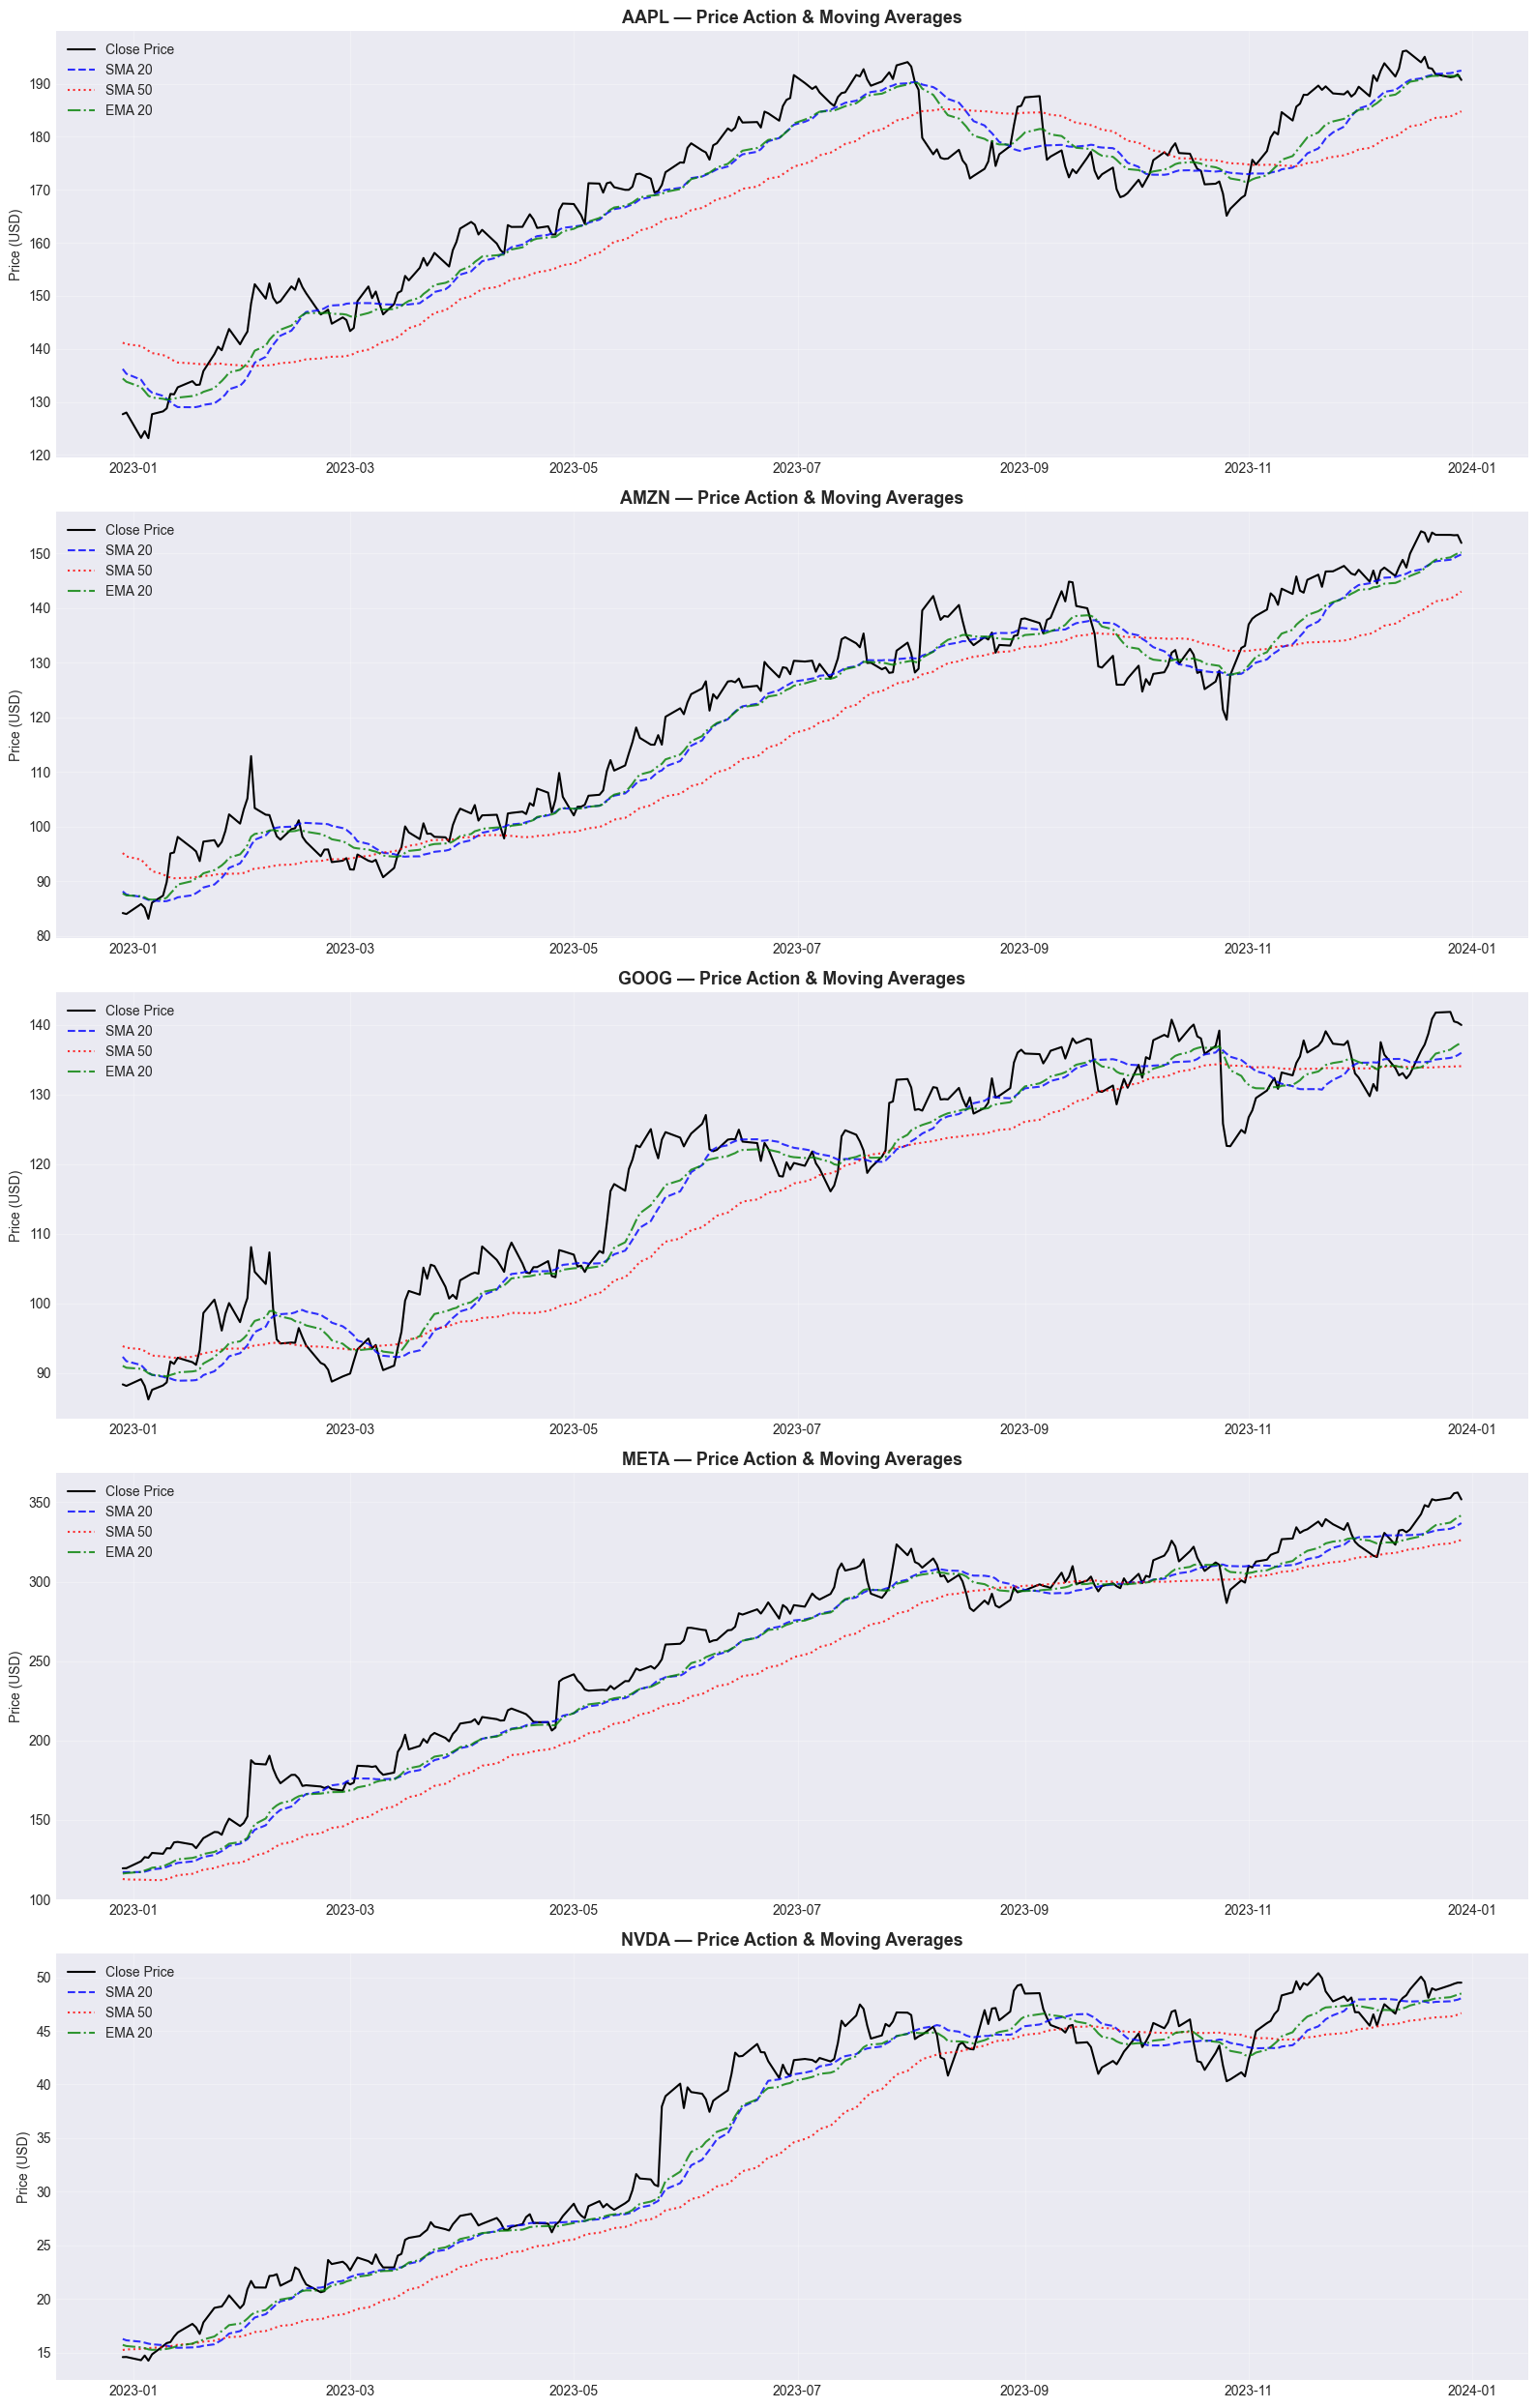

Moving averages chart saved


In [6]:
fig, axes = plt.subplots(len(stocks), 1, figsize=(16, 25))

for i, stock in enumerate(stocks):
    df = stock_data[stock].tail(252)  # last 1 year
    ax = axes[i]
    
    ax.plot(df['Date'], df['Close'], label='Close Price', 
            color='black', linewidth=1.5)
    ax.plot(df['Date'], df['SMA_20'], label='SMA 20', 
            linestyle='--', color='blue', alpha=0.8)
    ax.plot(df['Date'], df['SMA_50'], label='SMA 50', 
            linestyle=':', color='red', alpha=0.8)
    ax.plot(df['Date'], df['EMA_20'], label='EMA 20', 
            linestyle='-.', color='green', alpha=0.8)
    
    ax.set_title(f"{stock} — Price Action & Moving Averages", 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel("Price (USD)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/task2_moving_averages.png", dpi=100, bbox_inches='tight')
plt.show()
print("Moving averages chart saved")

## Moving Averages Interpretation

Moving averages smooth out daily price noise to reveal the underlying trend.

- When the **SMA 20 crosses above SMA 50** (Golden Cross), it signals the 
  beginning of a bullish trend — historically a buy signal.
- When the **SMA 20 crosses below SMA 50** (Death Cross), it signals a 
  bearish trend — historically a sell signal.
- The **EMA 20** reacts more quickly to recent price changes than the SMA 20,
  making it useful for detecting trend changes earlier.

All five stocks show clear upward price trends over the analysis period,
with moving averages confirming the bullish momentum in technology stocks.

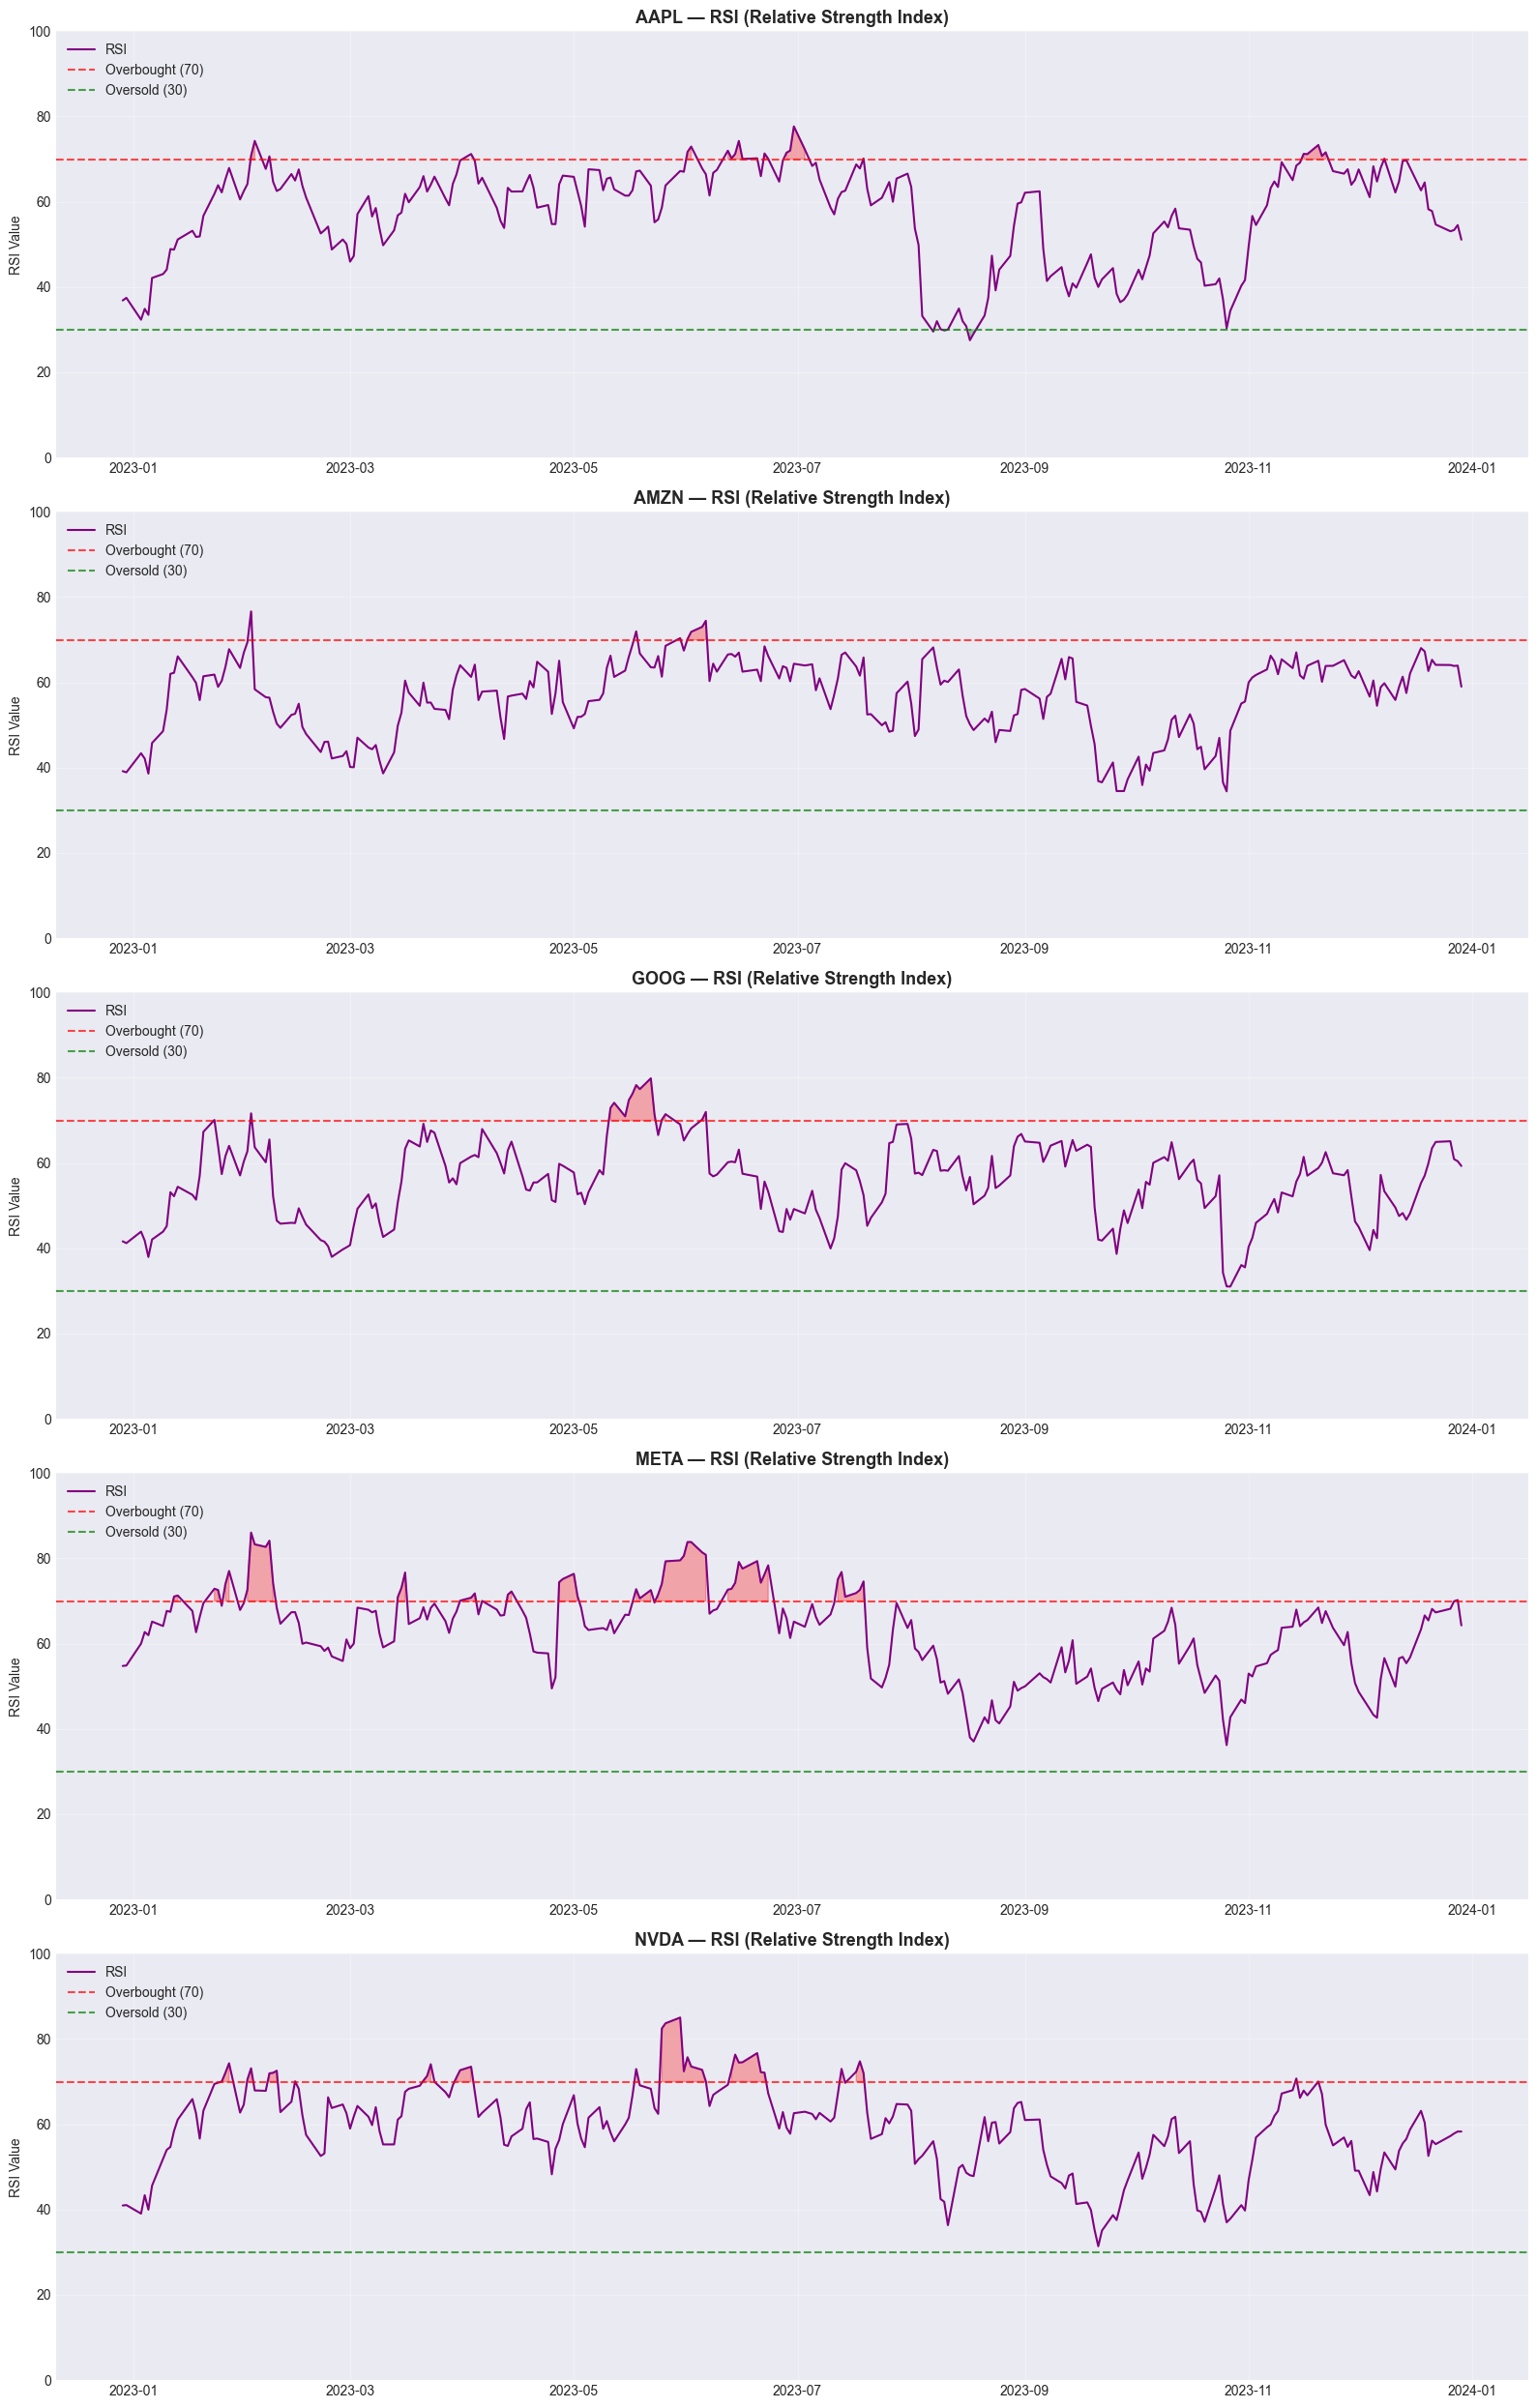

In [7]:
fig, axes = plt.subplots(len(stocks), 1, figsize=(16, 25))

for i, stock in enumerate(stocks):
    df = stock_data[stock].tail(252)
    ax = axes[i]
    
    ax.plot(df['Date'], df['RSI'], color='purple', linewidth=1.5, label='RSI')
    ax.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
    ax.axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
    ax.fill_between(df['Date'], df['RSI'], 70, 
                    where=(df['RSI'] >= 70), alpha=0.3, color='red')
    ax.fill_between(df['Date'], df['RSI'], 30, 
                    where=(df['RSI'] <= 30), alpha=0.3, color='green')
    
    ax.set_title(f"{stock} — RSI (Relative Strength Index)", 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel("RSI Value")
    ax.set_ylim(0, 100)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/task2_rsi.png", dpi=100, bbox_inches='tight')
plt.show()

## RSI Interpretation

The Relative Strength Index (RSI) measures the speed and magnitude of 
price changes on a scale from 0 to 100.

- **RSI above 70** (red zone): Stock is **overbought** — price may have risen 
  too fast and a pullback could be coming. Consider taking profits.
- **RSI below 30** (green zone): Stock is **oversold** — price may have fallen 
  too fast and a recovery could be coming. Consider buying opportunity.
- **RSI between 30-70**: Normal territory — no extreme signal.

For high-growth technology stocks like NVDA and AAPL, RSI frequently 
enters overbought territory during strong bull runs, meaning traditional 
RSI signals must be interpreted alongside trend context.

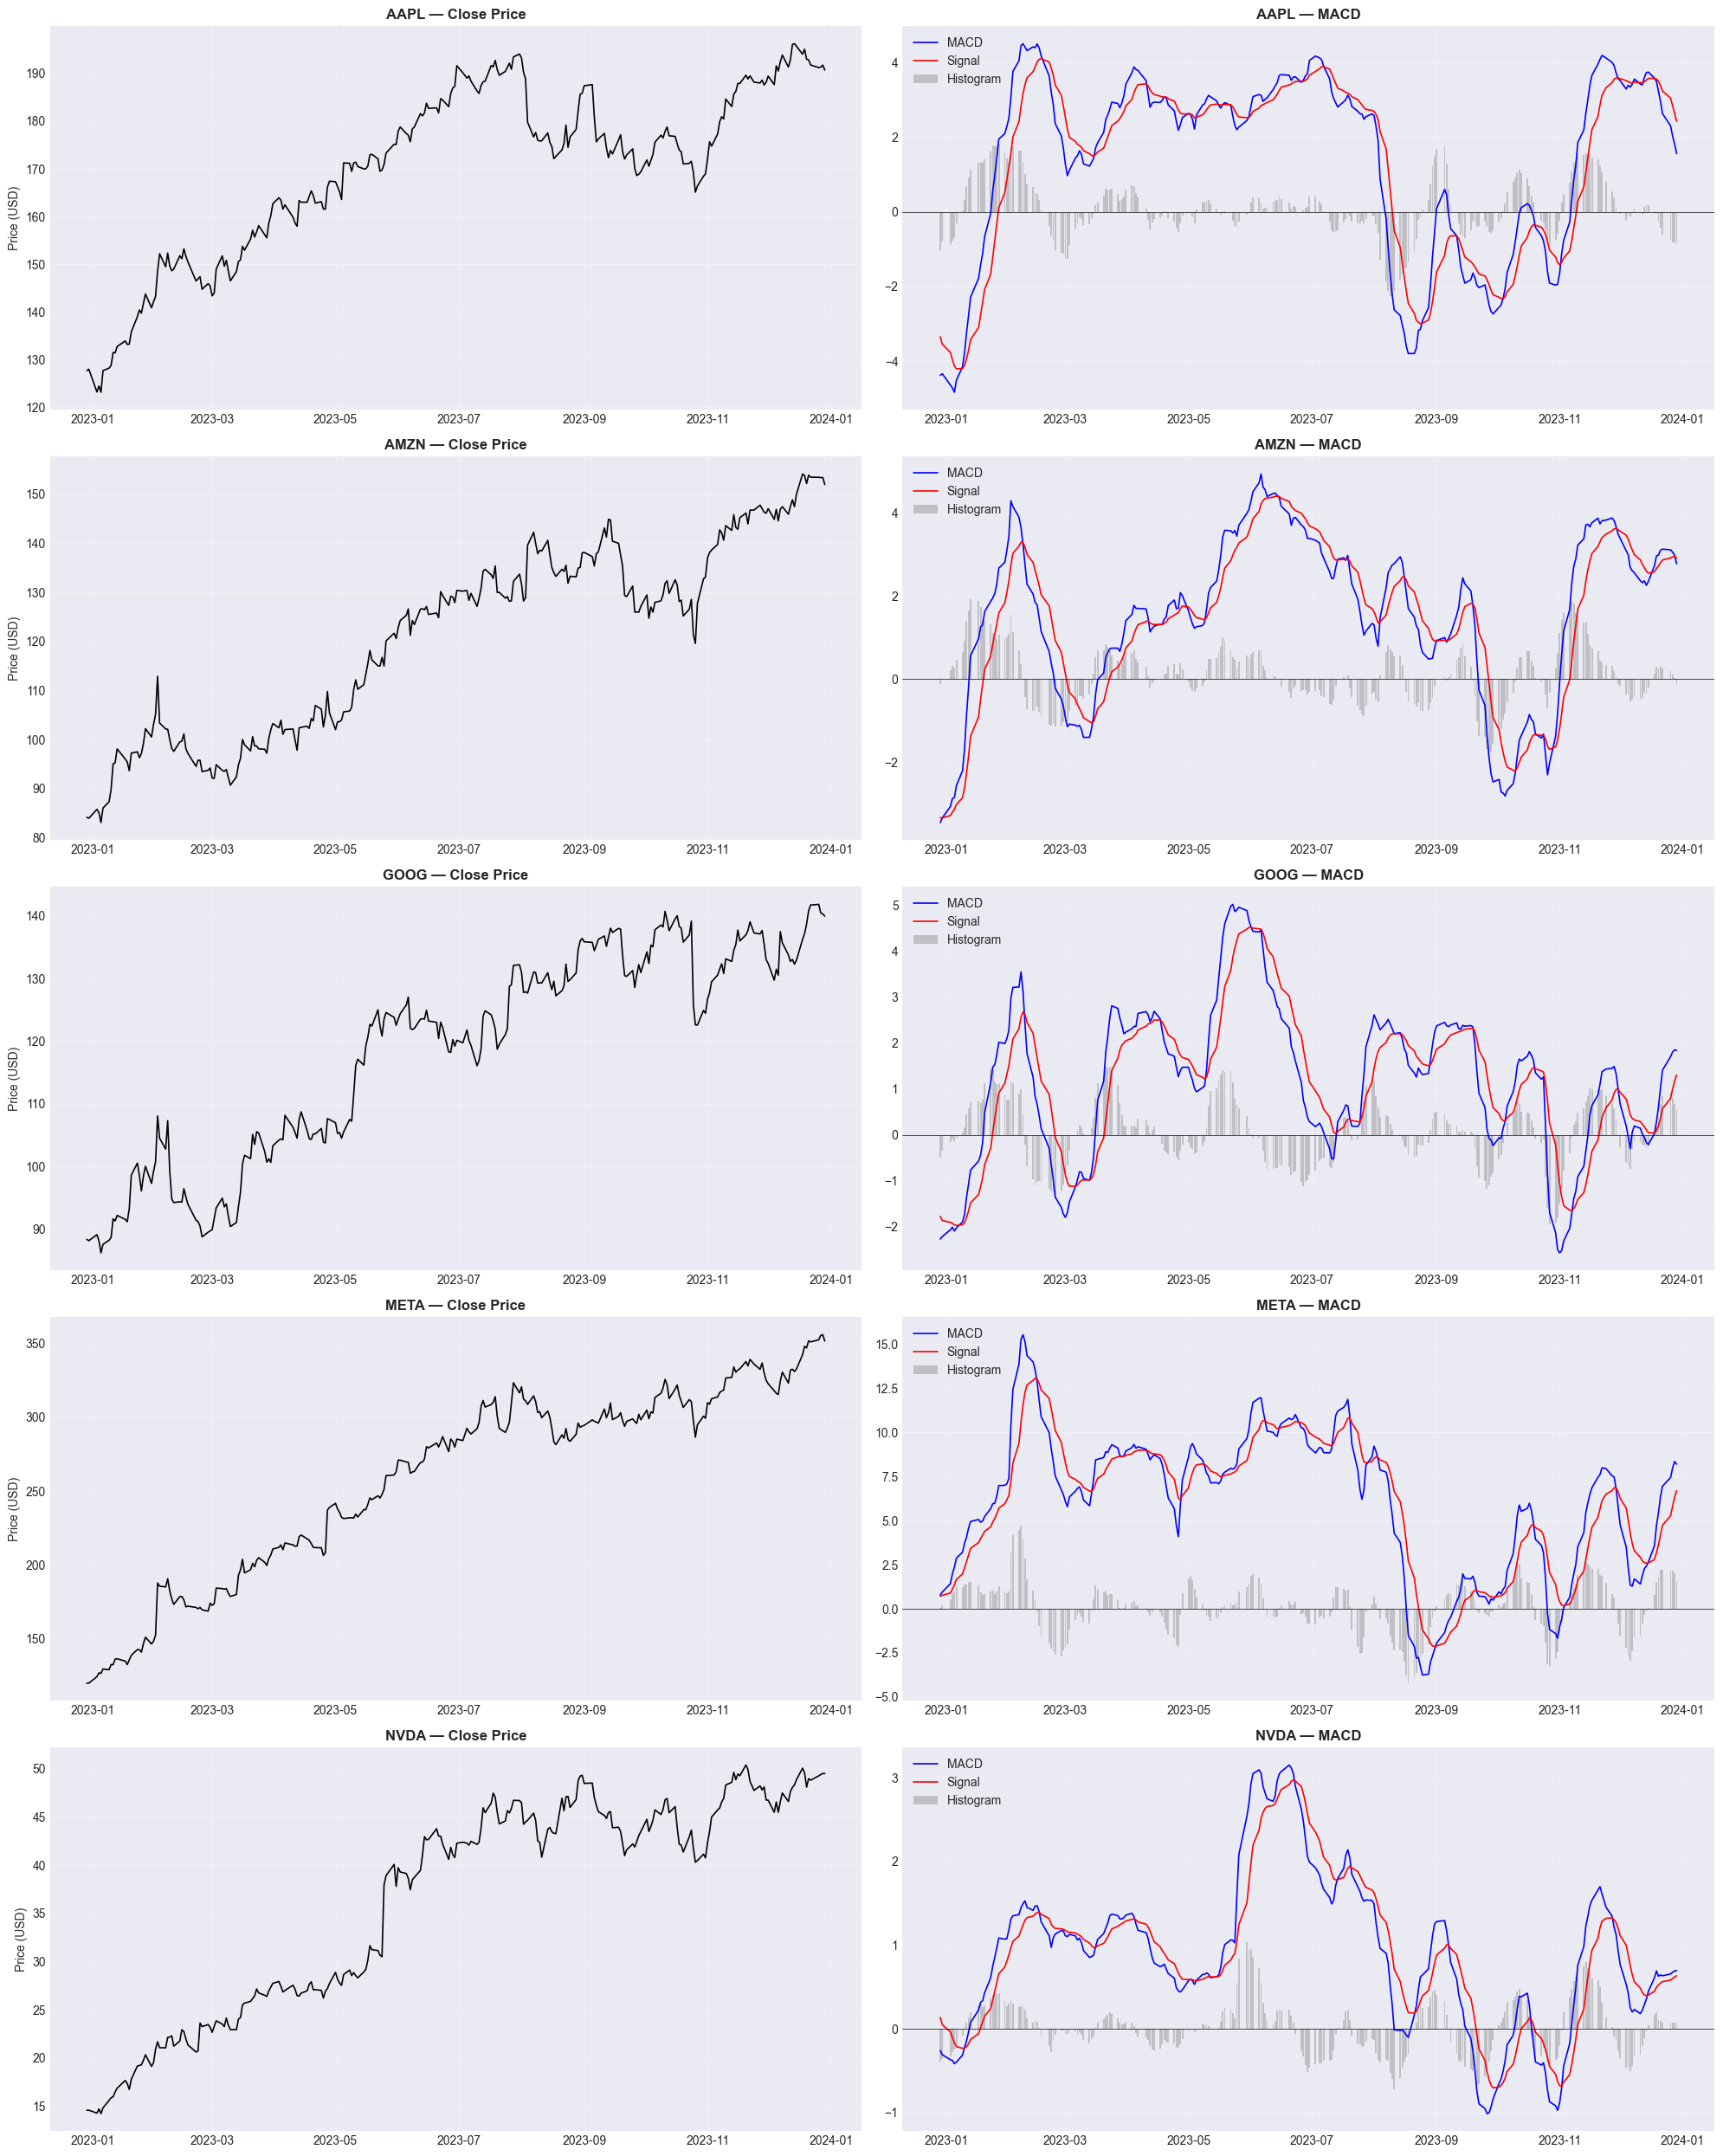

In [8]:
fig, axes = plt.subplots(len(stocks), 2, figsize=(20, 25))

for i, stock in enumerate(stocks):
    df = stock_data[stock].tail(252)
    
    # Price chart
    ax1 = axes[i, 0]
    ax1.plot(df['Date'], df['Close'], color='black', linewidth=1.2)
    ax1.set_title(f"{stock} — Close Price", fontweight='bold')
    ax1.set_ylabel("Price (USD)")
    ax1.grid(True, alpha=0.3)
    
    # MACD chart
    ax2 = axes[i, 1]
    ax2.plot(df['Date'], df['MACD'], label='MACD', color='blue', linewidth=1.2)
    ax2.plot(df['Date'], df['MACD_Signal'], label='Signal', 
             color='red', linewidth=1.2)
    ax2.bar(df['Date'], df['MACD_Hist'], label='Histogram', 
            color='gray', alpha=0.4)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_title(f"{stock} — MACD", fontweight='bold')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/task2_macd.png", dpi=100, bbox_inches='tight')
plt.show()

## MACD Interpretation

The Moving Average Convergence Divergence (MACD) measures momentum 
by comparing two exponential moving averages.

**Three components:**
- **MACD Line** (blue): Difference between 12-day and 26-day EMA
- **Signal Line** (red): 9-day EMA of the MACD line
- **Histogram** (gray): Difference between MACD and Signal lines

**Trading signals:**
- When MACD **crosses above** the Signal line → **Bullish** momentum building
- When MACD **crosses below** the Signal line → **Bearish** momentum building
- **Histogram growing** → momentum strengthening in current direction
- **Histogram shrinking** → momentum weakening, potential reversal

The MACD is particularly powerful for identifying momentum shifts 
before they become visible in the price chart alone.

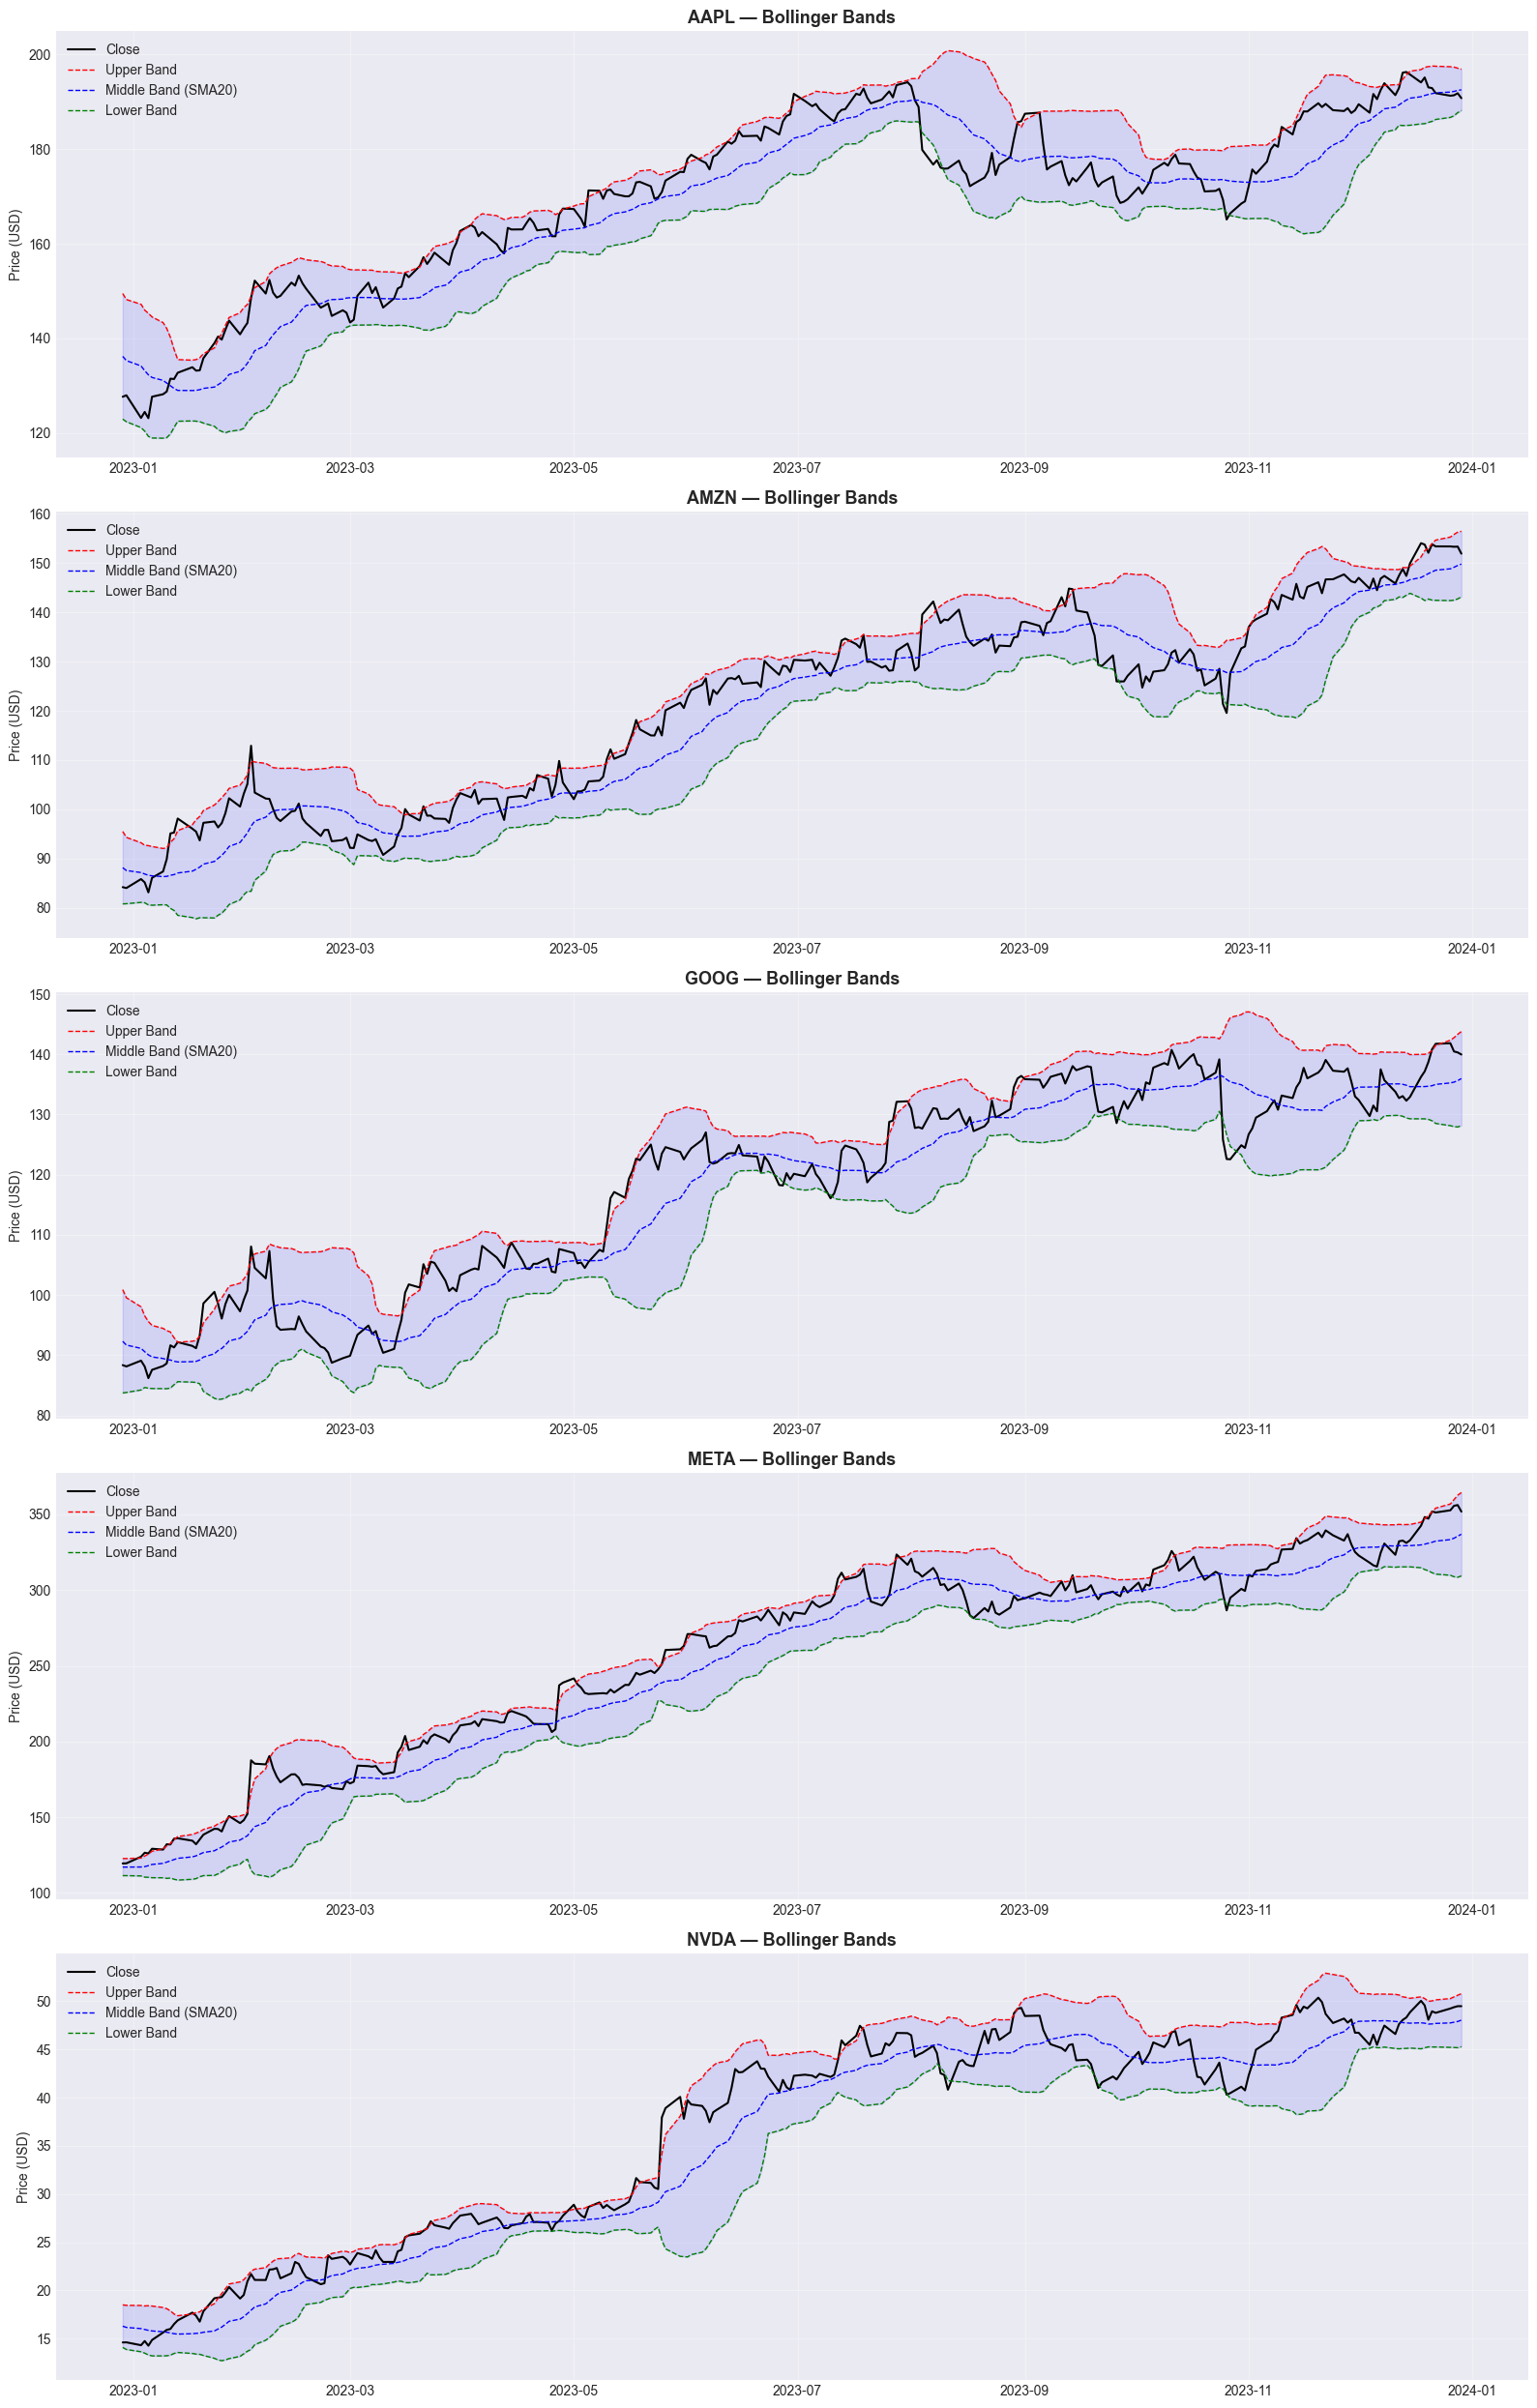

In [9]:
fig, axes = plt.subplots(len(stocks), 1, figsize=(16, 25))

for i, stock in enumerate(stocks):
    df = stock_data[stock].tail(252)
    ax = axes[i]
    
    ax.plot(df['Date'], df['Close'], color='black', linewidth=1.5, label='Close')
    ax.plot(df['Date'], df['BB_Upper'], color='red', 
            linestyle='--', linewidth=1, label='Upper Band')
    ax.plot(df['Date'], df['BB_Middle'], color='blue', 
            linestyle='--', linewidth=1, label='Middle Band (SMA20)')
    ax.plot(df['Date'], df['BB_Lower'], color='green', 
            linestyle='--', linewidth=1, label='Lower Band')
    ax.fill_between(df['Date'], df['BB_Lower'], df['BB_Upper'], 
                    alpha=0.1, color='blue')
    
    ax.set_title(f"{stock} — Bollinger Bands", fontsize=13, fontweight='bold')
    ax.set_ylabel("Price (USD)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/task2_bollinger_bands.png", dpi=100, bbox_inches='tight')
plt.show()

## Bollinger Bands Interpretation

Bollinger Bands consist of three lines plotted around price:
- **Upper Band**: SMA 20 + 2 standard deviations
- **Middle Band**: SMA 20 (simple moving average)
- **Lower Band**: SMA 20 - 2 standard deviations

**Key signals:**
- **Price touching upper band** → Potential overbought condition
- **Price touching lower band** → Potential oversold condition
- **Band squeeze** (bands narrowing) → Low volatility period, 
  often followed by a sharp price move in either direction
- **Band expansion** → High volatility, strong trending market

Bollinger Bands are particularly useful for spotting breakouts —
when price moves outside the bands with high volume, it often
signals the start of a strong new trend.

In [10]:
summary_rows = []

for stock in stocks:
    df = stock_data[stock]
    latest = df.iloc[-1]
    
    summary_rows.append({
        "Stock": stock,
        "Latest Close": f"${latest['Close']:.2f}",
        "SMA 20": f"${latest['SMA_20']:.2f}",
        "SMA 50": f"${latest['SMA_50']:.2f}",
        "RSI": f"{latest['RSI']:.1f}",
        "MACD": f"{latest['MACD']:.2f}",
        "Signal": "Overbought" if latest['RSI'] > 70 else 
                  "Oversold" if latest['RSI'] < 30 else "Neutral"
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Stock Latest Close  SMA 20  SMA 50  RSI MACD  Signal
 AAPL      $190.73 $192.49 $184.81 51.1 1.56 Neutral
 AMZN      $151.94 $149.82 $143.05 59.0 2.78 Neutral
 GOOG      $139.97 $135.98 $134.06 59.3 1.84 Neutral
 META      $351.79 $336.87 $326.26 64.3 8.19 Neutral
 NVDA       $49.50  $48.05  $46.66 58.3 0.70 Neutral


## Summary and Investment Signals

The technical indicator analysis reveals the current market positioning
of each stock:

- **RSI above 70**: Stock is in overbought territory — exercise caution 
  when entering new long positions
- **RSI below 30**: Stock is oversold — potential buying opportunity
- **Price above SMA 20 and SMA 50**: Strong bullish trend confirmed
- **MACD positive**: Upward momentum currently dominant

These signals should never be used in isolation. The most reliable 
trading decisions combine multiple confirming signals — for example, 
an oversold RSI combined with a MACD bullish crossover and price 
bouncing off the lower Bollinger Band provides much stronger 
conviction than any single indicator alone.

In the next task, we will combine these technical signals with 
news sentiment scores to measure whether positive news headlines 
predict positive price movements.